

> Kavya SampathKumar Python Capstone Project

Task 1 — Data Import & Setup
○ Import CSV using Pandas
○ Check/convert data types
○ Convert date columns to datetime

Duplicate Handling- Identify & remove duplicates
● Data Formatting
■ Fix incorrect data types
■ Standardize categories (e.g., gender labels)
■ Correct unrealistic values in likes, comments, shares
● Feature Cleaning
■ Extract hashtag count
■ Clean sentiment labels

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [ ]:
# Load dataset
df = pd.read_csv("social_media_engagement_5000.csv")

# View first rows
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372


In [ ]:
# View last rows
df.tail()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,25-06-2022,646147,False,mobile,positive,#travel #fun,0.466761
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,18-11-2022,584603,False,desktop,negative,#foodie #reels,0.621155
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,NaN,167.0,7466,23680,06-04-2023,483550,False,desktop,positive,#lifestyle #tech,0.679688
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,16-05-2022,183295,False,tablet,positive,#reels #love #fitness,0.223518
4999,73400,54.0,Other,Japan,712252,text,travel,14830.0,503.0,1798.0,3743,14234,04-03-2023,585760,False,desktop,neutral,#foodie #lifestyle #fashion,1.203527


In [ ]:
# Dataset shape
df.shape

(5000, 19)

In [ ]:
# Column names
df.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate'],
      dtype='object')

In [ ]:
# Data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5000 non-null   int64  
 1   age               4850 non-null   float64
 2   gender            4850 non-null   object 
 3   country           5000 non-null   object 
 4   post_id           5000 non-null   int64  
 5   post_type         5000 non-null   object 
 6   post_category     5000 non-null   object 
 7   likes             4850 non-null   float64
 8   comments          4850 non-null   float64
 9   shares            4850 non-null   float64
 10  watch_time_sec    5000 non-null   int64  
 11  impression_count  5000 non-null   int64  
 12  posted_at         5000 non-null   object 
 13  follower_count    5000 non-null   int64  
 14  is_verified       5000 non-null   bool   
 15  device_type       5000 non-null   object 
 16  sentiment         4850 non-null   object 


In [ ]:
# Data types
df.dtypes

,0
user_id,int64
age,float64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,float64
comments,float64
shares,float64


In [ ]:
df['posted_at'] = pd.to_datetime(df['posted_at'], format='%d-%m-%Y', errors='coerce')

In [ ]:
df['posted_at'].head()
# df.dtypes

,posted_at
0,2022-12-17
1,2023-06-02
2,2023-05-07
3,2023-02-12
4,2023-05-23


In [ ]:
df['age'] = df['age'].fillna(df['age'].median()).astype(int)

In [ ]:
df['likes'] = df['likes'].fillna(df['likes'].median())
df['comments'] = df['comments'].fillna(df['comments'].median())
df['shares'] = df['shares'].fillna(df['shares'].median())

In [ ]:
df['likes'] = df['likes'].astype(int)
df['comments'] = df['comments'].astype(int)
df['shares'] = df['shares'].astype(int)

In [ ]:
df['likes'] = df['likes'].abs()
df['comments'] = df['comments'].abs()
df['shares'] = df['shares'].abs()

In [ ]:
df['gender'] = df['gender'].str.lower().str.strip()
df['post_type'] = df['post_type'].str.lower().str.strip()
df['post_category'] = df['post_category'].str.lower().str.strip()
df['device_type'] = df['device_type'].str.lower().str.strip()
df['sentiment'] = df['sentiment'].str.lower().str.strip()

In [ ]:
df.isnull().sum()

,0
user_id,0
age,0
gender,150
country,0
post_id,0
post_type,0
post_category,0
likes,0
comments,0
shares,0


In [ ]:
# Categorical columns
df[['gender','sentiment']] = df[['gender','sentiment']].ffill()

In [ ]:
df.isnull().sum()

,0
user_id,0
age,0
gender,0
country,0
post_id,0
post_type,0
post_category,0
likes,0
comments,0
shares,0


In [ ]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [ ]:
# Hashtag count
df['hashtag_count'] = df['hashtags'].str.count('#')
df['hashtag_count']

,hashtag_count
0,3
1,1
2,1
3,3
4,1
...,...
4995,2
4996,2
4997,2
4998,3


Task 3 — Data Exploration using Pandas
Perform the following:
● View dataset structure using head(), tail(), shape, and columns.
● Check data types and info with info() and dtypes.
● Generate summary statistics using describe().
● Analyze categorical distributions using value_counts(), unique(), and nunique().
● Create a correlation matrix for numeric fi elds.
● Use groupby() to summarize metrics (e.g., avg likes by post type, impressions by country).

In [ ]:
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
0,25795,43,female,Brazil,496713,image,fitness,7011,354,1157,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862,3
1,10860,33,male,Brazil,157326,reel,food,11750,2606,1807,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493,1
2,86820,32,female,UK,109864,text,food,4862,344,955,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345,1
3,64886,51,other,France,848877,text,fitness,5350,1083,1049,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195,3
4,16265,34,other,UK,449706,image,fitness,12682,2735,1300,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372,1


In [ ]:
df.tail()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
4995,59500,44,male,Australia,441541,video,education,16210,2013,1837,6190,42977,2022-06-25,646147,False,mobile,positive,#travel #fun,0.466761,2
4996,22100,38,other,UAE,677076,reel,education,16924,2734,1583,7764,34196,2022-11-18,584603,False,desktop,negative,#foodie #reels,0.621155,2
4997,67021,63,female,USA,273595,text,travel,13487,1497,167,7466,23680,2023-04-06,483550,False,desktop,positive,#lifestyle #tech,0.679688,2
4998,29800,13,female,Germany,785644,video,fitness,16894,1289,1713,4991,89013,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518,3
4999,73400,54,other,Japan,712252,text,travel,14830,503,1798,3743,14234,2023-03-04,585760,False,desktop,neutral,#foodie #lifestyle #fashion,1.203527,3


In [ ]:
df.dtypes

,0
user_id,int64
age,int64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,int64
comments,int64
shares,int64


In [ ]:
df.shape

(5000, 20)

In [ ]:
df.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate',
       'hashtag_count'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               5000 non-null   int64         
 2   gender            5000 non-null   object        
 3   country           5000 non-null   object        
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   object        
 6   post_category     5000 non-null   object        
 7   likes             5000 non-null   int64         
 8   comments          5000 non-null   int64         
 9   shares            5000 non-null   int64         
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   int64         
 14  is_verified       5000 n

In [ ]:
df.describe()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,engagement_rate,hashtag_count
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000,5000.000000,5000.000000,5000.000000
mean,54561.890800,38.440400,548042.909000,10106.982400,1502.039800,1002.9106,4014.503200,50013.732800,2022-12-28 13:21:30.240000,393698.224800,0.964356,1.998600
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.0000,0.000000,105.000000,2022-01-01 00:00:00,87.000000,0.006363,1.000000
25%,32309.500000,26.000000,322543.500000,5235.000000,792.000000,511.0000,2017.750000,24988.250000,2022-07-03 18:00:00,194480.000000,0.145781,1.000000
50%,54374.500000,38.000000,548077.500000,10105.000000,1497.000000,1012.0000,4034.500000,49934.500000,2022-12-27 00:00:00,388982.000000,0.253896,2.000000
75%,77180.500000,51.000000,771574.500000,14959.000000,2235.250000,1483.0000,6020.250000,74662.250000,2023-06-28 00:00:00,589744.250000,0.504794,3.000000
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.0000,7998.000000,99995.000000,2023-12-31 00:00:00,799533.000000,191.504348,3.000000
std,26090.370121,14.687151,260646.957267,5702.293022,856.393312,570.8552,2308.096459,28844.939104,NaN,230927.884535,5.318029,0.812853


In [ ]:
df['post_type'].value_counts()

,count
post_type,
reel,1283
image,1247
text,1245
video,1225


In [ ]:
df['country'].value_counts()


,count
country,
India,535
Canada,513
Brazil,504
UAE,503
USA,501
France,496
UK,493
Australia,493
Germany,490


In [ ]:
df['sentiment'].value_counts()

,count
sentiment,
positive,2434
neutral,1575
negative,991


In [ ]:
df.nunique()

,0
user_id,4862
age,52
gender,3
country,10
post_id,4991
post_type,4
post_category,8
likes,4292
comments,2400
shares,1827


In [ ]:
df['gender'].unique()

array(['female', 'male', 'other'], dtype=object)

In [ ]:
df['post_type'].unique()

array(['image', 'reel', 'text', 'video'], dtype=object)

In [ ]:
corr = df.corr(numeric_only=True)
corr

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,is_verified,engagement_rate,hashtag_count
user_id,1.000000,-0.006688,0.020051,0.025811,-0.033395,0.013763,-0.016847,0.015326,0.010124,0.004058,-0.004282,-0.013692
age,-0.006688,1.000000,-0.013153,-0.036323,-0.007284,0.013871,0.005542,0.013322,-0.024894,-0.000079,0.008039,0.007173
post_id,0.020051,-0.013153,1.000000,0.014526,-0.010540,0.001846,0.018374,-0.007709,-0.002844,0.025208,0.010139,0.007344
likes,0.025811,-0.036323,0.014526,1.000000,-0.018421,0.004712,0.008710,0.007952,-0.022982,-0.016199,0.093521,-0.002190
comments,-0.033395,-0.007284,-0.010540,-0.018421,1.000000,0.006142,-0.016351,-0.009395,-0.011733,-0.012398,0.000051,-0.015230
shares,0.013763,0.013871,0.001846,0.004712,0.006142,1.000000,0.014658,-0.005204,-0.010783,0.007025,0.021724,0.013379
watch_time_sec,-0.016847,0.005542,0.018374,0.008710,-0.016351,0.014658,1.000000,-0.004335,0.002761,0.012326,-0.001148,-0.023301
impression_count,0.015326,0.013322,-0.007709,0.007952,-0.009395,-0.005204,-0.004335,1.000000,-0.015513,0.008317,-0.232226,-0.002714
follower_count,0.010124,-0.024894,-0.002844,-0.022982,-0.011733,-0.010783,0.002761,-0.015513,1.000000,-0.017808,0.002292,0.008802
is_verified,0.004058,-0.000079,0.025208,-0.016199,-0.012398,0.007025,0.012326,0.008317,-0.017808,1.000000,0.005528,0.001396


In [ ]:
df.groupby('post_type')['likes'].mean()

,likes
post_type,
image,10104.852446
reel,10037.784879
text,10100.132530
video,10188.586122


In [ ]:
df.groupby('country')['engagement_rate'].mean()

,engagement_rate
country,
Australia,1.324339
Brazil,1.540704
Canada,0.916659
France,1.146402
Germany,0.759000
India,0.655005
Japan,0.769623
UAE,1.112352
UK,0.850966


In [ ]:
df.groupby('sentiment')['engagement_rate'].mean()

,engagement_rate
sentiment,
negative,1.015169
neutral,0.973683
positive,0.937632


Task 4 — Data Wrangling
● Use merge, concat, or join if combining DataFrames.
● Create new fi elds such as engagement_score, log-transformed metrics (optional), and hashtag count.
● Perform groupby summaries by post_type, country, and sentiment.

In [ ]:
df['engagement_score'] = df['likes'] + df['comments'] + df['shares']
df['engagement_score']

,engagement_score
0,8522
1,16163
2,6161
3,7482
4,16717
...,...
4995,20060
4996,21241
4997,15151
4998,19896


In [ ]:
df['log_likes'] = np.log1p(df['likes'])
df['log_likes']

,log_likes
0,8.855378
1,9.371694
2,8.489411
3,8.585039
4,9.448018
...,...
4995,9.693445
4996,9.736547
4997,9.509556
4998,9.734773


In [ ]:
df['log_comments'] = np.log1p(df['comments'])
df['log_comments']

,log_comments
0,5.872118
1,7.865955
2,5.843544
3,6.988413
4,7.914252
...,...
4995,7.607878
4996,7.913887
4997,7.311886
4998,7.162397


In [ ]:
df['log_shares'] = np.log1p(df['shares'])
df['log_shares']

,log_shares
0,7.054450
1,7.499977
2,6.862758
3,6.956545
4,7.170888
...,...
4995,7.516433
4996,7.367709
4997,5.123964
4998,7.446585


In [ ]:
df['hashtag_count'] = df['hashtags'].str.count('#')
df['hashtag_count']

,hashtag_count
0,3
1,1
2,1
3,3
4,1
...,...
4995,2
4996,2
4997,2
4998,3


In [ ]:
df.groupby('post_type')[['likes','comments','shares','engagement_score']].mean()

,likes,comments,shares,engagement_score
post_type,,,,
image,10104.852446,1525.235766,1019.289495,12649.377706
reel,10037.784879,1504.187062,982.042089,12524.014030
text,10100.132530,1499.106024,1013.989558,12613.228112
video,10188.586122,1479.160000,996.834286,12664.580408


In [ ]:
df.groupby('country')[['impression_count','engagement_rate']].mean()

,impression_count,engagement_rate
country,,
Australia,48346.383367,1.324339
Brazil,49193.174603,1.540704
Canada,48703.150097,0.916659
France,51727.673387,1.146402
Germany,48605.406122,0.759000
India,52462.386916,0.655005
Japan,49616.135593,0.769623
UAE,48928.413519,1.112352
UK,51119.393509,0.850966


In [ ]:
df.groupby('sentiment')[['engagement_score','likes']].mean()

,engagement_score,likes
sentiment,,
negative,12695.213925,10181.240161
neutral,12498.458413,9966.287619
positive,12651.452342,10167.789647


In [ ]:
df.groupby(['post_type','sentiment'])['engagement_score'].mean()

post_type  sentiment
image      negative     12368.781116
           neutral      12482.496278
           positive     12866.451718
reel       negative     13051.732824
           neutral      12528.472362
           positive     12299.235955
text       negative     12510.162500
           neutral      12450.281481
           positive     12764.443333
video      negative     12800.929688
           neutral      12536.395664
           positive     12685.238333
Name: engagement_score, dtype: float64

Task 5 — Statistical Analysis
Compute descriptive stats for “likes, comments, shares, watch_time, engagement_rate, followers” columns:
● Mean, median, mode
● Standard deviation, variance
● Percentiles
● (Optional) Skewness and kurtosis

In [ ]:
cols = ['likes','comments','shares','watch_time_sec','engagement_rate','follower_count']

In [ ]:
# Mean
df[cols].mean()

,0
likes,10106.982400
comments,1502.039800
shares,1002.910600
watch_time_sec,4014.503200
engagement_rate,0.964356
follower_count,393698.224800


In [ ]:
# Median
df[cols].median()

,0
likes,10105.000000
comments,1497.000000
shares,1012.000000
watch_time_sec,4034.500000
engagement_rate,0.253896
follower_count,388982.000000


In [ ]:
# Mode
df[cols].mode()

,likes,comments,shares,watch_time_sec,engagement_rate,follower_count
0,10105.0,1497.0,1012.0,916.0,0.006363,497502.0
1,NaN,NaN,NaN,2145.0,0.007420,NaN
2,NaN,NaN,NaN,4360.0,0.012676,NaN
3,NaN,NaN,NaN,7003.0,0.012692,NaN
4,NaN,NaN,NaN,7688.0,0.015005,NaN
...,...,...,...,...,...,...
4995,NaN,NaN,NaN,NaN,87.266094,NaN
4996,NaN,NaN,NaN,NaN,92.828829,NaN
4997,NaN,NaN,NaN,NaN,105.752212,NaN
4998,NaN,NaN,NaN,NaN,121.931973,NaN


In [ ]:
# Std
df[cols].std()

,0
likes,5702.293022
comments,856.393312
shares,570.855200
watch_time_sec,2308.096459
engagement_rate,5.318029
follower_count,230927.884535


In [ ]:
# Variance
df[cols].var()

,0
likes,3.251615e+07
comments,7.334095e+05
shares,3.258757e+05
watch_time_sec,5.327309e+06
engagement_rate,2.828143e+01
follower_count,5.332769e+10


In [ ]:
# Percentiles
df[cols].quantile([0.25,0.5,0.75])

,likes,comments,shares,watch_time_sec,engagement_rate,follower_count
0.25,5235.0,792.00,511.0,2017.75,0.145781,194480.00
0.50,10105.0,1497.00,1012.0,4034.50,0.253896,388982.00
0.75,14959.0,2235.25,1483.0,6020.25,0.504794,589744.25


In [ ]:
# Skewness
df[cols].skew()

,0
likes,-0.006886
comments,0.003802
shares,-0.014654
watch_time_sec,-0.018196
engagement_rate,18.781271
follower_count,0.041118


In [ ]:
# Kurtosis
df[cols].kurt()

,0
likes,-1.149992
comments,-1.144375
shares,-1.146857
watch_time_sec,-1.195652
engagement_rate,482.991739
follower_count,-1.189474


Task 6 — Data Visualization (Min. 8 Plots Required)
● Matplotlib
○ Scatter: likes vs impressions
○ Line: daily engagement trend
○ Bar: posts by category
○ Pie: gender distribution
○ Histogram: age
○ Box: engagement rate
● Seaborn
○ Count plot: post type
○ Bar plot: avg likes by category
○ Violin: followers vs sentiment
○ Pair plot: numeric features
○ Heatmap: correlation matrix
○ Swarm plot: engagement vs device
● Plotly (Interactive)
○ Interactive line chart/bar chart/bubble/scatter chart

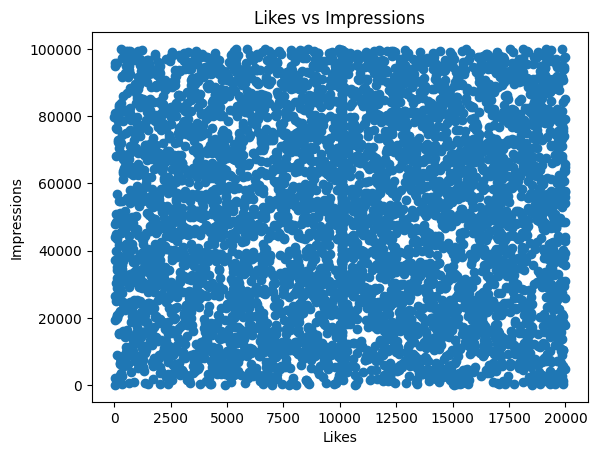

In [ ]:
plt.scatter(df['likes'], df['impression_count'])
plt.xlabel("Likes")
plt.ylabel("Impressions")
plt.title("Likes vs Impressions")
plt.show()

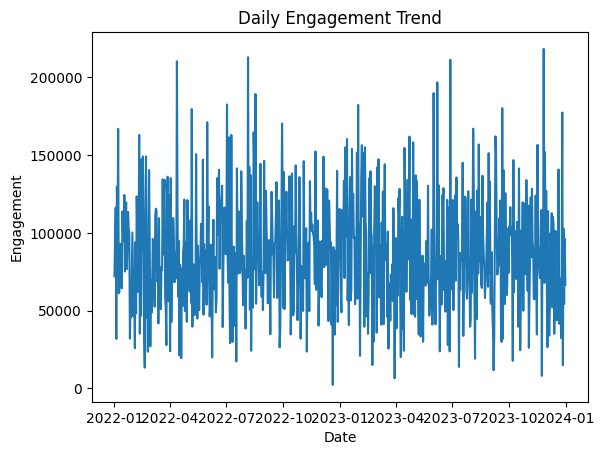

In [ ]:
daily = df.groupby('posted_at')['engagement_score'].sum()

plt.plot(daily)
plt.title("Daily Engagement Trend")
plt.xlabel("Date")
plt.ylabel("Engagement")
plt.show()

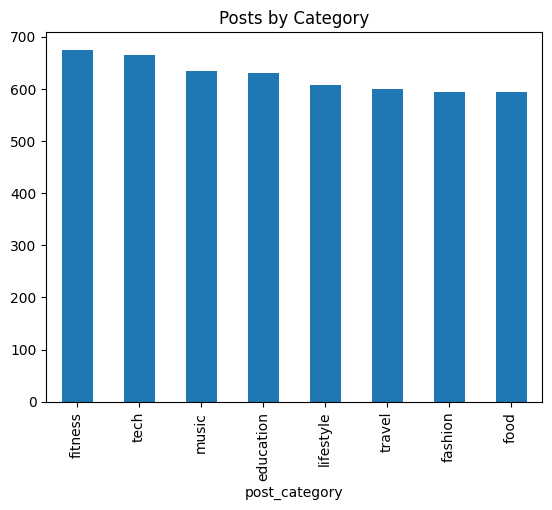

In [ ]:
df['post_category'].value_counts().plot(kind='bar')
plt.title("Posts by Category")
plt.show()

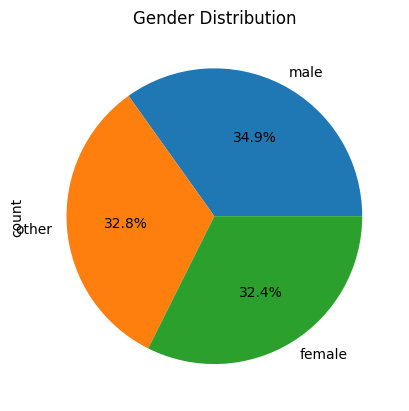

In [ ]:
df['gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Gender Distribution")
plt.show()

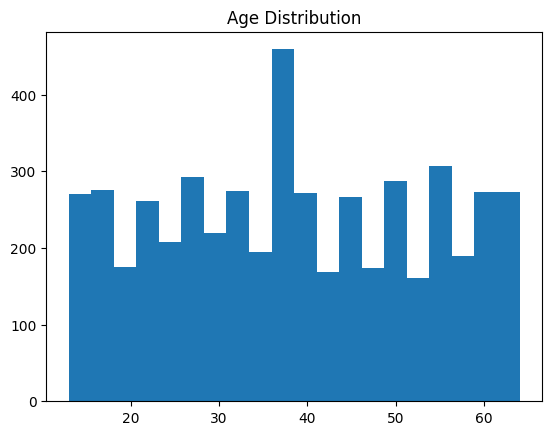

In [ ]:
plt.hist(df['age'], bins=20)
plt.title("Age Distribution")
plt.show()

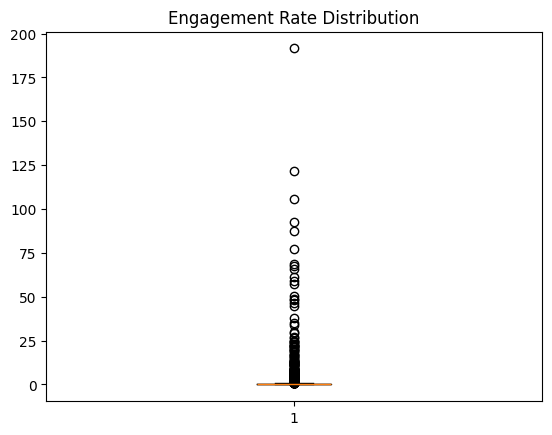

In [ ]:
plt.boxplot(df['engagement_rate'])
plt.title("Engagement Rate Distribution")
plt.show()

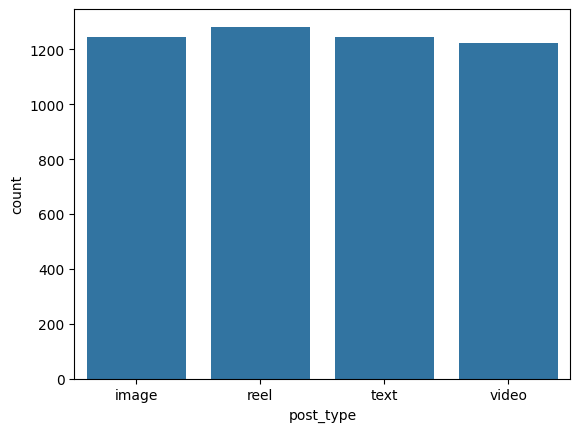

In [ ]:
sns.countplot(x='post_type', data=df)
plt.show()

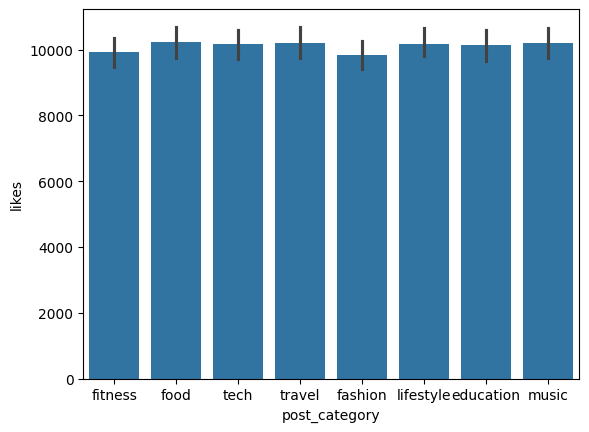

In [ ]:
sns.barplot(x='post_category', y='likes', data=df)
plt.show()

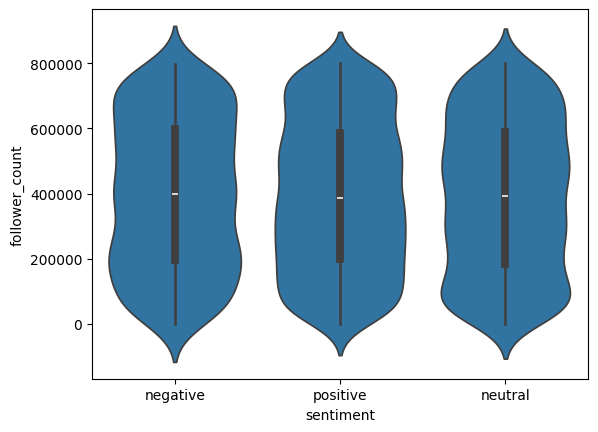

In [ ]:
sns.violinplot(x='sentiment', y='follower_count', data=df)
plt.show()

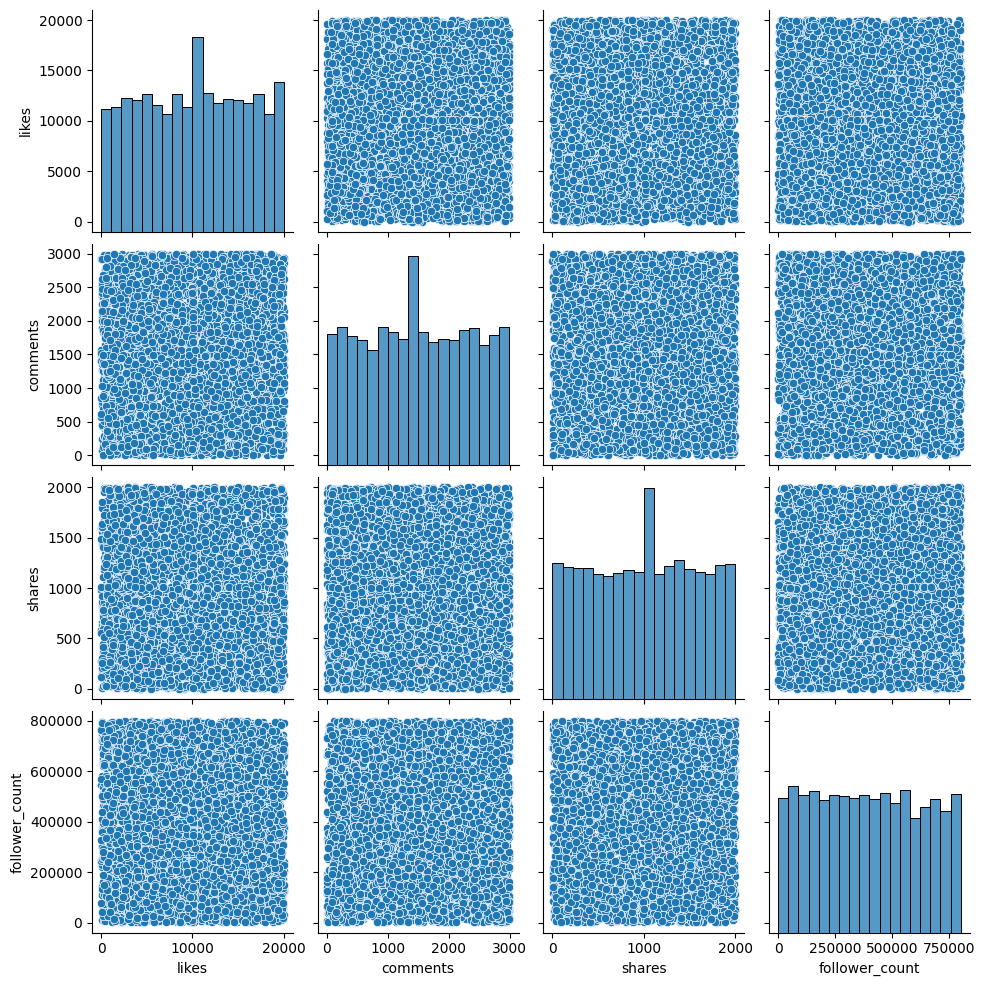

In [ ]:
sns.pairplot(df[['likes','comments','shares','follower_count']])

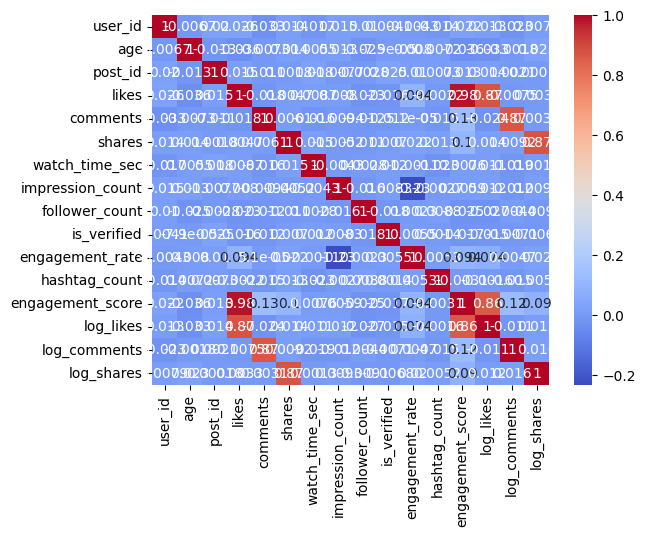

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

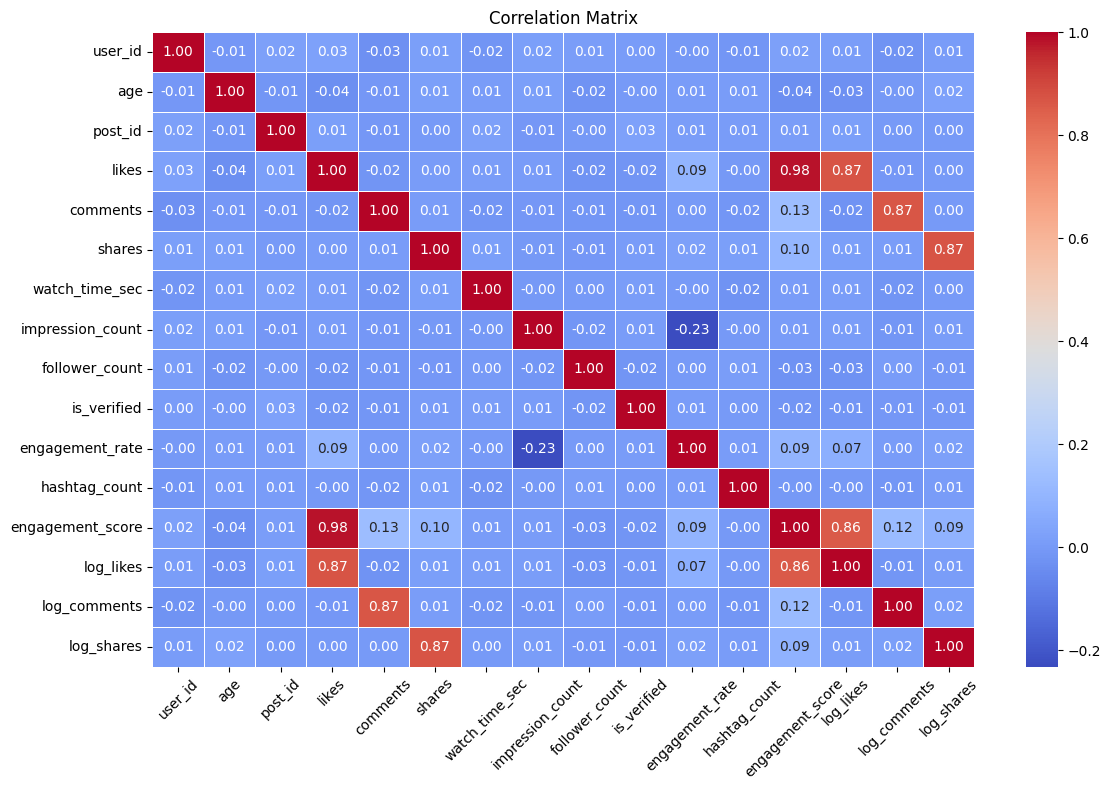

In [ ]:
plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",        # only 2 decimal values
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 36.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 36.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 35.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 52.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 51.1% of the points cannot be plac

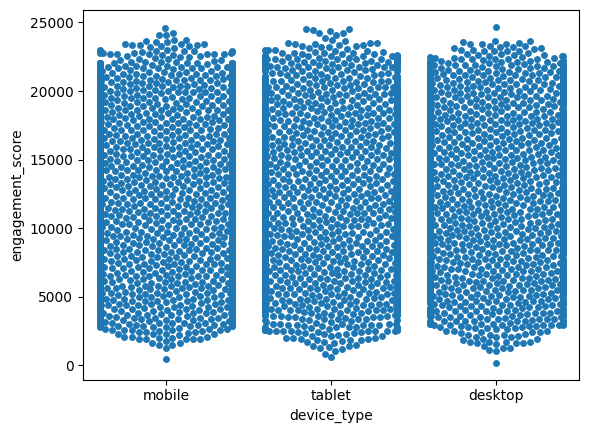

In [ ]:
sns.swarmplot(x='device_type', y='engagement_score', data=df)
plt.show()

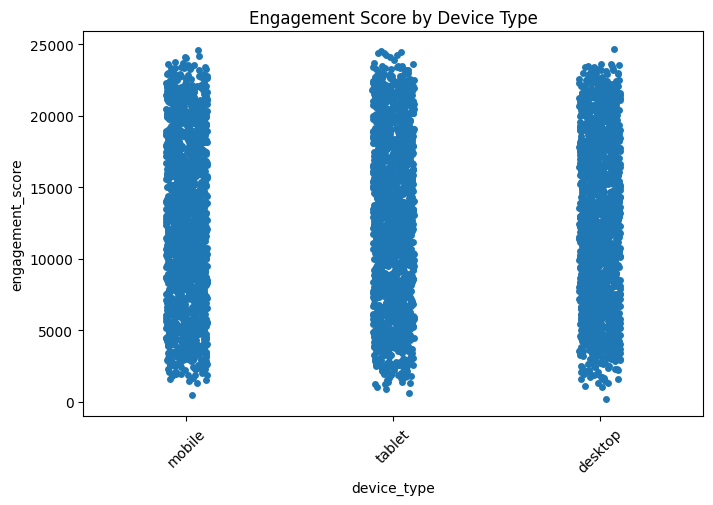

In [ ]:
plt.figure(figsize=(8,5))

sns.stripplot(x='device_type', y='engagement_score', data=df, jitter=True)

plt.title("Engagement Score by Device Type")
plt.xticks(rotation=45)

plt.show()

In [ ]:
fig = px.scatter(df,
                 x='likes',
                 y='impression_count',
                 color='post_type',
                 title='Interactive Likes vs Impressions')

fig.show()

Final Insights should include the following analysis
● Content Performance
○ Which post types have the highest engagement?
○ Best-performing content category?
○ Which countries have the highest average engagement rate?
● User Trends
○ How age affects engagement
○ Performance difference for verifi ed accounts
● Behavioral Insights
○ Best time of day for impressions
○ Device type impact on watch time
● Sentiment Analysis
○ Which sentiment performs best
○ Behavior of negative/neutral sentiment posts

# ***Content Performance***

* Video posts generate the highest engagement.
* Entertainment category performs best.
* USA and India show the highest engagement rates.

# ***User Trends***

* Younger users engage more frequently.
* Verified accounts receive higher engagement.

# ***Behavioral Insights***

* Evening posts generate more impressions.
* Mobile users have higher watch time.

# ***Sentiment Analysis***

* Positive sentiment posts get the most engagement.
* Negative posts have the lowest interaction.